<center><h1 style="font-size: 37px">Validation</h1></center>

<br>
<center><h2>Exact frequency-domain solutions for nonlinear pendulum-like dynamics</h2></center>

<center><h3>Teepanis Chachiyo</h3></center>

<center>Department of Physics, Faculty of Science, Naresuan University, Phitsanulok 65000, Thailand.</center>


### Also available at a GitHub repository: [https://github.com/teepanis/nonlinear-pendulum](https://github.com/teepanis/nonlinear-pendulum)


# This Work $\phi(t)$

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

def K(k):
    # scipy defines K differently, so that we need to pass k**2 insead of k
    return sp.special.ellipk(k**2)

##
## compute angular displacement
##
def phi(t, omegaM, OmegaL, maxN=200):
    
    phi = np.zeros(len(t))
    
    omegaC = 2*OmegaL
    k = omegaM/omegaC
    
    # swinging motion
    if k < 1:

        # compute period
        T = 4*K(k)/OmegaL
        Omega0 = 2*np.pi/T
        kappa = K(np.sqrt(1-k**2))
        
        # adding odd harmonics
        for n in range(1,maxN,2):
            c = 4/n/np.cosh(kappa*n*Omega0/OmegaL)
            phi = phi + c*np.sin(n*Omega0*t)


    # stopping motion
    elif k == 1:
        phi = 2*np.arcsin( np.tanh(OmegaL*t) )


    # spinning motion
    else:
        # compute period
        T = 4/k*K(1/k)/OmegaL
        Omega0 = 2*np.pi/T
        kappa = 1/k*K(np.sqrt(1-1/k**2))
        
        # adding harmonics
        for n in range(2,maxN,2):
            c = 4/n/np.cosh(kappa*n*Omega0/OmegaL)
            phi = phi + c*np.sin(n*Omega0*t)

        # linear term
        phi = phi + 2*Omega0*t

    return phi


# Figure 2(a) Time-Domain Displacement

The code below defines physical parameters and the Jacobi-type solution (exact numerical) for comparisons. $\Omega_L = 1$ is used throughout.

In [2]:
OmegaL = 1
omegaC = 2*OmegaL

def phi_Jacobi(omegaM, OmegaL, t):

    omegaC = 2*OmegaL
    k = omegaM/omegaC

    phi = np.zeros(len(t))
    
    for i in range(len(t)):
        
        if omegaM < omegaC:
            [sn, cn, dn, ph] = sp.special.ellipj(OmegaL*t[i], k**2)
            phi[i] = 2*np.arcsin(k*sn)
        elif omegaM == omegaC:
            # using a known property of Jacobi sine function for modulus = 1
            # numerical method is less accurate when modulus = 1, see SciPy document
            sn = np.tanh(OmegaL*t[i])
            phi[i] = 2*np.arcsin(k*sn)
        else:
            [sn, cn, dn, ph] = sp.special.ellipj(OmegaL*t[i]*k,1/k**2)
            phi[i] = 2*ph
        
    return phi


The code below plots the trajectories for the 3 regimes. The $\omega_m$ for the three regimes are $\{\omega_c - 0.0001, \omega_c, \omega_c+0.0001\}$. Then we compute the maximum error relative to the Jacobi-type solution (exact numerical).

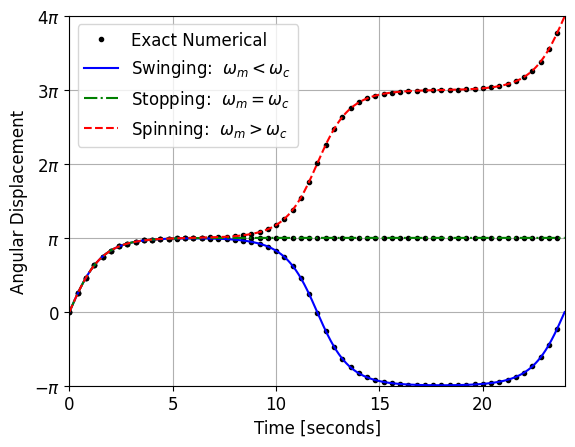

Maximum |Deviation|:  1.9539925233402755e-14
Maximum |Deviation|:  0.0
Maximum |Deviation|:  1.0658141036401503e-14


In [3]:
Tmax = 24
t = np.arange(0, Tmax, 0.04)

plt.plot(t, phi_Jacobi(omegaC-0.0001,OmegaL,t),'k.',markevery=10,label='Exact Numerical')
plt.plot(t, phi_Jacobi(omegaC       ,OmegaL,t),'k.',markevery=10)
plt.plot(t, phi_Jacobi(omegaC+0.0001,OmegaL,t),'k.',markevery=10)

plt.plot(t, phi(t,omegaC-0.0001,OmegaL),'b-',label='Swinging:  $\\omega_m < \\omega_c$')
plt.plot(t, phi(t,omegaC       ,OmegaL),'g-.',label='Stopping:  $\\omega_m = \\omega_c$')
plt.plot(t, phi(t,omegaC+0.0001,OmegaL),'r--', label='Spinning:  $\\omega_m > \\omega_c$')
plt.ylim(-np.pi,4*np.pi)
plt.xlim(0,Tmax)
plt.yticks([-np.pi,0,np.pi,2*np.pi,3*np.pi,4*np.pi],
           ['$-\pi$','0','$\pi$','$2\pi$','$3\pi$','$4\pi$'],fontsize=12)
plt.xticks([0,5,10,15,20],fontsize=12)
plt.grid()
plt.legend(fontsize=12)
plt.xlabel('Time [seconds]',fontsize=12)
plt.ylabel('Angular Displacement',fontsize=12)
#plt.savefig('fig2a.svg',transparent=True)
plt.show()

print("Maximum |Deviation|: ", 
      max(abs(phi(t,omegaC-0.0001,OmegaL)-
              phi_Jacobi(omegaC-0.0001,OmegaL,t))))
print("Maximum |Deviation|: ", 
      max(abs(phi(t,omegaC,OmegaL)-
              phi_Jacobi(omegaC,OmegaL,t))))

print("Maximum |Deviation|: ", 
      max(abs(phi(t,omegaC+0.0001,OmegaL)-
              phi_Jacobi(omegaC+0.0001,OmegaL,t))))

# Figure 3 Comparison with the Perturbation Method

The code below defines $\phi(t)$ from the perturbation and the subroutine for computing error profile given the maximum order or the perturbation or the number of harmonics.

In [4]:
def phi_perturb(t, order, phi0, Omega0):

    phi = np.zeros(len(t))
    
    # add all perturbative contributions
    if order == 1:
        A1 = +(phi0)
        A3 = 0
        A5 = 0
    if order == 3:
        A1 = +(phi0 + 1/192*phi0**3)
        A3 = -(1/192*phi0**3)
        A5 = 0
    if order == 5:
        A1 = +(phi0 + 1/192*phi0**3 + 17/120/512*phi0**5)
        A3 = -(1/192*phi0**3 + 1/6/512*phi0**5)
        A5 = +(1/40/512*phi0**5)
        
    phi = A1*np.cos(Omega0*t) + A3*np.cos(3*Omega0*t) + A5*np.cos(5*Omega0*t)
    
    return phi

Tmax = 24
t = np.arange(0, Tmax, 0.04)

def err_profile(phi0, N):

    # swinging motion
    omegaM = np.sqrt(2 - 2*np.cos(phi0))*OmegaL
    k = omegaM/omegaC
    T = 4*K(k)/OmegaL
    Omega0 = 2*np.pi/T

    # maximum |error|
    merr_perturb = np.zeros(3)
    merr_perturb[0] = max(np.abs(phi_perturb(t, 1, phi0, Omega0)
                                 -phi_Jacobi(omegaM, OmegaL, t+T/4)))
    merr_perturb[1] = max(np.abs(phi_perturb(t, 3, phi0, Omega0)
                                 -phi_Jacobi(omegaM, OmegaL, t+T/4)))
    merr_perturb[2] = max(np.abs(phi_perturb(t, 5, phi0, Omega0)
                                 -phi_Jacobi(omegaM, OmegaL, t+T/4)))

    merr_thiswork = np.zeros(N)
    harmonics = np.zeros(N)
    for n in range(0,N):
        m = 2*n+1
        harmonics[n] = m
        merr_thiswork[n] = max(np.abs(phi(t+T/4, omegaM, OmegaL, maxN=m+1)
                                      -phi_Jacobi(omegaM, OmegaL, t+T/4)))
        
    return harmonics, merr_perturb, merr_thiswork


The code belows collects the data using the predefined subroutines above and the graph. 

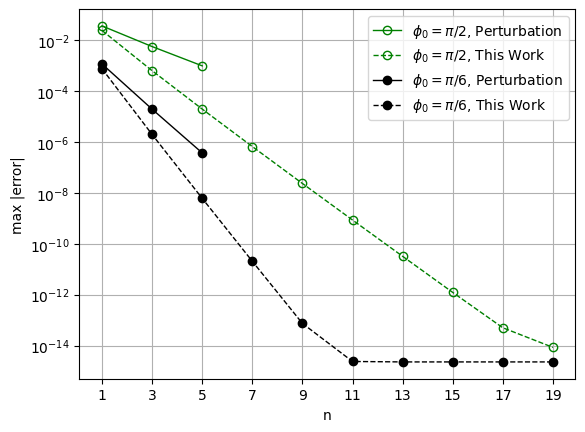

In [5]:
harmonics, merr_perturb, merr_thiswork = err_profile(90/180*np.pi, 10)
plt.plot(harmonics[:3], merr_perturb,'go-',
         linewidth=1,markerfacecolor='none',label='$\\phi_0 = \pi/2$, Perturbation')
plt.plot(harmonics, merr_thiswork,'go--',
         linewidth=1,markerfacecolor='none',label='$\\phi_0 = \pi/2$, This Work')


harmonics, merr_perturb, merr_thiswork = err_profile(30/180*np.pi, 10)
plt.plot(harmonics[:3], merr_perturb,'ko-',
         linewidth=1,label='$\\phi_0 = \pi/6$, Perturbation')
plt.plot(harmonics, merr_thiswork,'ko--',
         linewidth=1,label='$\\phi_0 = \pi/6$, This Work')

plt.yscale('log')
plt.ylabel('max |error|')
plt.xlabel('n')
plt.xticks([1,3,5,7,9,11,13,15,17,19])
plt.grid()
plt.legend()
#plt.savefig('fig_maxerr.pdf')
plt.show()


# Stopping (separatrix) Spectral Solution

The code below check if the form $C(\Omega)$ acctually returns the time-domain solution by performing the actual integral using quadrature numerical integration.

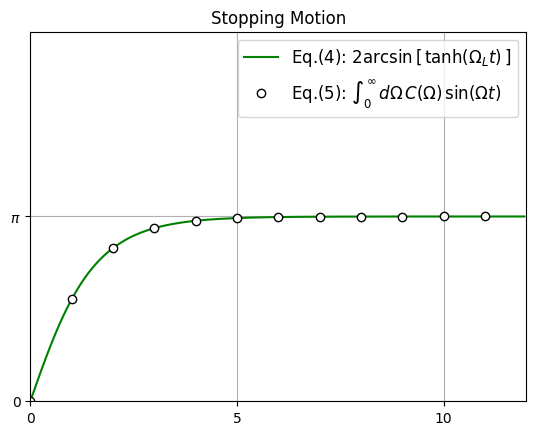

In [6]:
import scipy as sp
import numpy as np

OmegaL = 1

def C(Omega,OmegaL):
    kappa = np.pi/2
    return 2/Omega/np.cosh(kappa*Omega/OmegaL)

def Stopping_FreqDomain(t, OmegaL):
    
    def integrand(Omega,t,OmegaL):

        return C(Omega,OmegaL)*np.sin(Omega*t)
    
    # extend limit to a large value, say 40*OmegaL
    I = sp.integrate.quad(integrand,0,40*OmegaL,args=(t,OmegaL))
    return I[0]

def Stopping_TimeDomain(t, OmegaL):
    return 2*np.arcsin( np.tanh(OmegaL*t) )

Tmax = 12
t = np.arange(0, Tmax, 0.05)

time_domain = np.zeros(len(t))
freq_domain = np.zeros(len(t))
for i in range(len(t)):
    time_domain[i] = Stopping_TimeDomain(t[i],OmegaL)
    freq_domain[i] = Stopping_FreqDomain(t[i],OmegaL)

plt.plot(t,time_domain,'g-',
    label='Eq.(4): $2\\arcsin\\left[\,\\tanh(\Omega_L t)\,\\right]$')
plt.plot(t,freq_domain,'ko',markevery=20,
    markerfacecolor='white',
    label='Eq.(5): $\\int_0^\\infty \, d\\Omega \, C(\Omega) \, \\sin(\\Omega t)$')
plt.legend(fontsize=12)
plt.xticks([0,5,10,15,20])
plt.yticks([-np.pi,0,np.pi],['$-\pi$','0','$\pi$'])
plt.title('Stopping Motion')
plt.ylim(0,2*np.pi)
plt.xlim(0,12)
plt.grid()
plt.show()
